In [1]:
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import pandas as pd

plotting.setup_mpl()

### Tire degradation

In this section, I will analyze how different tire compounds (Soft, Medium, and Hard) lose performance over time.

In [2]:
race = fastf1.get_session(2021, 'Spain', 'R')
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (156.29 MB) C:\Users\Sprzetowo\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 44 completed the race distance 00:00.083000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '77', '16', '11', '3', '55', '4', '31', '10', '18', '7

In [3]:
laps = race.laps

#data cleaning
clean_laps = laps.pick_quicklaps()
clean_laps = clean_laps.loc[clean_laps['TrackStatus'] == '1']

clean_laps = clean_laps.copy()
clean_laps['LapTimeSec'] = clean_laps['LapTime'].dt.total_seconds()

To perform an accurate tire analysis, I must filter out "noisy" data that doesn't reflect the true performance of the tires. I perform the following steps:
1. Removing Non-Racing Laps (pit-in and pit-out laps)
2. Removing laps where the driver made a mistake, spun, or encountered a local yellow flag.
3. Keeping laps where the `TrackStatus` is '1' (Green Track), ensuring no Safety Car or VSC periods interfere with the lap times.

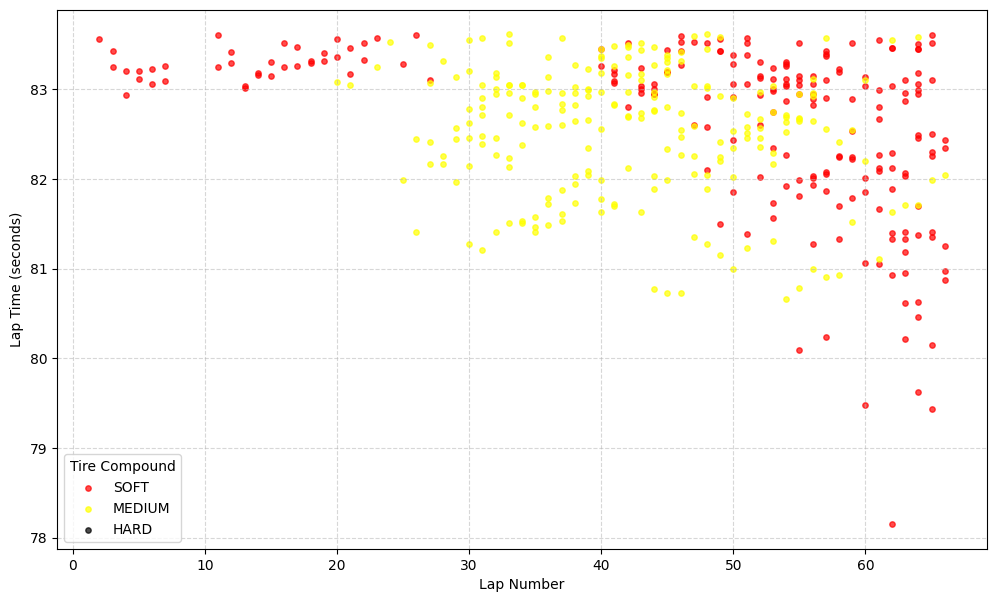

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'black'}

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    df = clean_laps[clean_laps['Compound'] == compound]
    
    ax.scatter(df['LapNumber'], df['LapTimeSec'], 
               color=compound_colors[compound], 
               label=compound, 
               s=15, 
               alpha=0.7)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(title="Tire Compound")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Conclusions

**Compound Performance Gap:** The Soft tires (Red) clearly provide the fastest initial lap times, sitting lower on the Y-axis. However, notice how the "cloud" of red dots ends early, showing their shorter lifespan.

**The Degradation Slope:** As the lap number increases, we see a general upward trend in lap times for the Mediums (Yellow). This is the "degradation" – the rubber wears out and the grip levels drop.

**Fuel Correction Effect:** A fascinating observation is the "dip" in times towards the end of the race (laps 60+). Even on older tires, the cars become faster because they are nearly empty of fuel, making the car significantly lighter.

**Strategy Outcome:** The data shows why the two-stop strategy was dominant; the pace drop-off on high-mileage tires (the upward climb of the dots) eventually makes a fresh set of tires much faster, even with the time lost in the pits.

### Top Speed vs. Tire Compound
In this section, I investigate whether the tire compound affects the absolute top speed of the car.

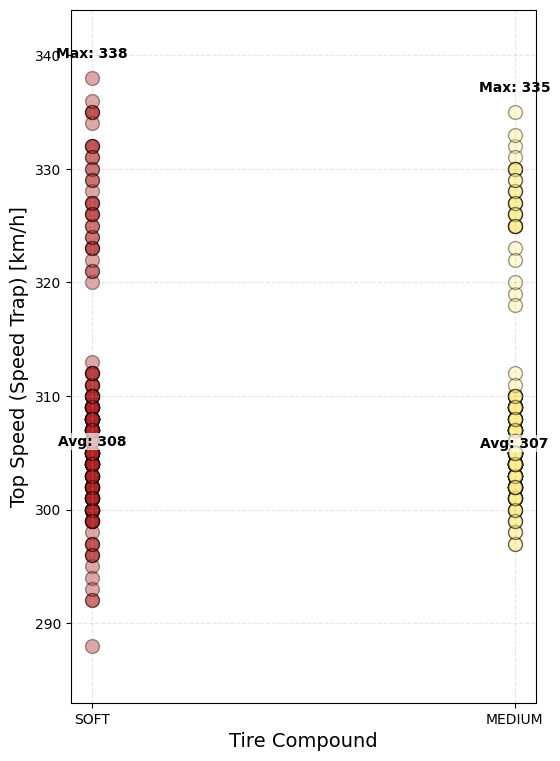

In [6]:
fig, ax = plt.subplots(figsize=(6, 9))

compounds = ['SOFT', 'MEDIUM', 'HARD']
compound_colours = {'SOFT': '#B22222', 'MEDIUM': '#FFEE8C', 'HARD': '#DBDBDC'}

all_speeds = []

for compound in compounds:
    df_compound = clean_laps[clean_laps['Compound'] == compound]
    
    speeds = df_compound['SpeedST'].dropna().tolist() # dropna() usuwa puste błędy
    
    if len(speeds) > 0:
        x_coords = [compound] * len(speeds)
        
        ax.scatter(x_coords, speeds, color=compound_colours[compound], 
                    s=100, alpha=0.4, edgecolor='black')
        
        avg_speed = sum(speeds) / len(speeds)
        max_speed = max(speeds)
        all_speeds.extend(speeds) 
        

        ax.text(compound, avg_speed - 1.5, f"Avg: {int(avg_speed)}", 
                ha='center', va='top', fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        ax.text(compound, max_speed + 1.5, f"Max: {int(max_speed)}", 
                ha='center', va='bottom', fontweight='bold', color='black')

ax.set_ylabel('Top Speed (Speed Trap) [km/h]', fontsize=14)
ax.set_xlabel('Tire Compound', fontsize=14)

if all_speeds:
    ax.set_ylim(min(all_speeds) - 5, max(all_speeds) + 6)
    
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()

### Conclusions
**Fuel Load Effect:** Soft tires are heavily utilized at the start of the race when cars are fully loaded with ~110kg of fuel, reducing overall top speed.
**Aerodynamics over Mechanical Grip:** Softer compounds provide immense mechanical grip for cornering and acceleration, but straight-line speed is dictated heavily by drag, DRS (Drag Reduction System), and slipstream effects, which often occur later in the race on harder tires.

However, we still can see the difference between medium and soft compund (hard wasn't used). Drivers reach higher top speed on soft tires (max: 338, average: 308) than on medium tires (max: 335, average: 307).

### The influence of temperature on tyre wear
In this section, I would like to analyze if there is an influance of temperature on tyre degradation.

In [19]:
import seaborn as sns

In [27]:
laps_plot = clean_laps.copy()

laps_plot['LapTime_s'] = laps_plot['LapTime'].dt.total_seconds()

In [28]:
weather = race.weather_data.copy()

laps_plot = laps_plot.sort_values('Time')
weather = weather.sort_values('Time')

In [29]:
laps_weather = pd.merge_asof(laps_plot, weather, on='Time', direction='backward')

In [32]:
compounds_to_plot = ['SOFT', 'MEDIUM', 'HARD']
laps_weather = laps_weather[laps_weather['Compound'].isin(compounds_to_plot)]

laps_weather = laps_weather.dropna(subset=['LapTime_s', 'TrackTemp'])
laps_weather = laps_weather[laps_weather['LapTime_s'] < 95]

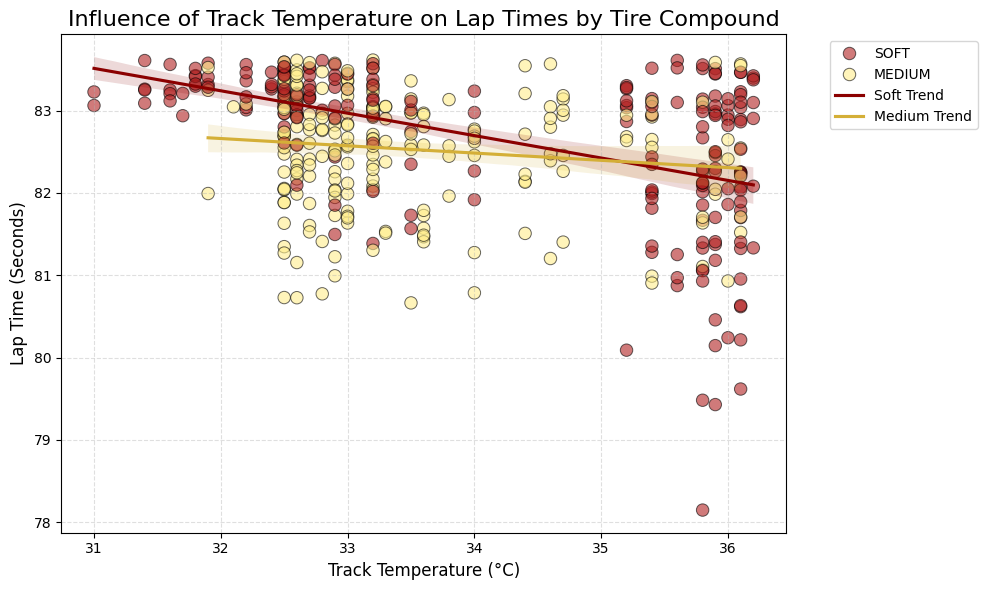

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=laps_weather, 
    x='TrackTemp',       # Temperatura toru na osi X
    y='LapTime_s',       # Czas okrążenia na osi Y
    hue='Compound',      # Kolor kropki zależy od opony
    palette={'SOFT': '#B22222', 'MEDIUM': '#FFEE8C', 'HARD': '#DBDBDC'},
    s=80, 
    edgecolor='black', 
    alpha=0.6
)

sns.regplot(data=laps_weather[laps_weather['Compound'] == 'SOFT'], x='TrackTemp', y='LapTime_s', scatter=False, color='#8B0000', label='Soft Trend')
sns.regplot(data=laps_weather[laps_weather['Compound'] == 'MEDIUM'], x='TrackTemp', y='LapTime_s', scatter=False, color='#D4AF37', label='Medium Trend')

plt.title('Influence of Track Temperature on Lap Times by Tire Compound', fontsize=16)
plt.xlabel('Track Temperature (°C)', fontsize=12)
plt.ylabel('Lap Time (Seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()